In [33]:
!pip install pandas scikit-learn matplotlib joblib

In [34]:
import pandas as pd

data = {

        "text": [
        "I absolutely loved this product",
        "The service was excellent",
        "Amazing experience",
        "I am very happy with the purchase",
        "This product is wonderful",
        "The quality is fantastic",
        "Really enjoyed using it",
        "Excellent customer service",
        "I would definitely recommend it",
        "Very satisfied with the experience",
        "The product works perfectly",
        "I am impressed with the quality",
        "This was a great purchase",
        "Fantastic experience overall",
        "I love this product",
        "The delivery was quick and excellent",
        "Very useful and easy to use",
        "The staff was friendly",
        "This is one of my best purchases",
        "Extremely happy with the result",

        "The product is terrible",
        "I hated the experience",
        "Very poor quality",
        "The service was horrible",
        "I am extremely disappointed",
        "This product does not work",
        "Worst purchase ever",
        "The experience was frustrating",
        "I would not recommend this",
        "The quality is very bad",
        "Completely dissatisfied",
        "The service was disappointing",
        "This was a waste of money",
        "The product broke immediately",
        "Very unhappy with the purchase",
        "Terrible customer service",
        "I regret buying this",
        "The product is useless",
        "Very poor experience",
        "I am not satisfied at all",

        "The product arrived today",
        "The service was provided yesterday",
        "I received the package",
        "The product is available",
        "The store opens at nine",
        "I used the product today",
        "The order was delivered",
        "The phone is on the table",
        "The customer visited the store",
        "The product costs five hundred",
        "The package contains a charger",
        "The shop is near my house",
        "The delivery took two days",
        "The application is installed",
        "The meeting starts at ten",
        "The product has three colors",
        "The store is open today",
        "The customer placed an order",
        "The item is currently available"
    ],

    "sentiment": (
        ["Positive"] * 20 +
        ["Negative"] * 20 +
        ["Neutral"] * 19
    )
}

df = pd.DataFrame(data)

print(df.head())
print("\nDataset shape:", df.shape)
print("\nSentiment distribution:")
print(df["sentiment"].value_counts())

                                text sentiment
0    I absolutely loved this product  Positive
1          The service was excellent  Positive
2                 Amazing experience  Positive
3  I am very happy with the purchase  Positive
4          This product is wonderful  Positive

Dataset shape: (59, 2)

Sentiment distribution:
sentiment
Positive    20
Negative    20
Neutral     19
Name: count, dtype: int64


In [35]:
import re

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(preprocess_text)

df[["text", "clean_text"]].head()

,text,clean_text
0,I absolutely loved this product,i absolutely loved this product
1,The service was excellent,the service was excellent
2,Amazing experience,amazing experience
3,I am very happy with the purchase,i am very happy with the purchase
4,This product is wonderful,this product is wonderful


In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"],
    df["sentiment"],
    test_size=0.2,
    random_state=42,
    stratify=df["sentiment"]
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 47
Testing samples: 12


In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=5000
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training feature shape:", X_train_tfidf.shape)
print("Testing feature shape:", X_test_tfidf.shape)

Training feature shape: (47, 216)
Testing feature shape: (12, 216)


In [38]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

print("Model training completed successfully.")

Model training completed successfully.


In [39]:
y_pred = model.predict(X_test_tfidf)

print("Predictions:")
print(y_pred)

Predictions:
['Positive' 'Positive' 'Negative' 'Neutral' 'Positive' 'Negative'
 'Positive' 'Positive' 'Neutral' 'Neutral' 'Negative' 'Positive']


In [40]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.5833333333333334

Classification Report:
              precision    recall  f1-score   support

    Negative       0.33      0.25      0.29         4
     Neutral       1.00      0.75      0.86         4
    Positive       0.50      0.75      0.60         4

    accuracy                           0.58        12
   macro avg       0.61      0.58      0.58        12
weighted avg       0.61      0.58      0.58        12



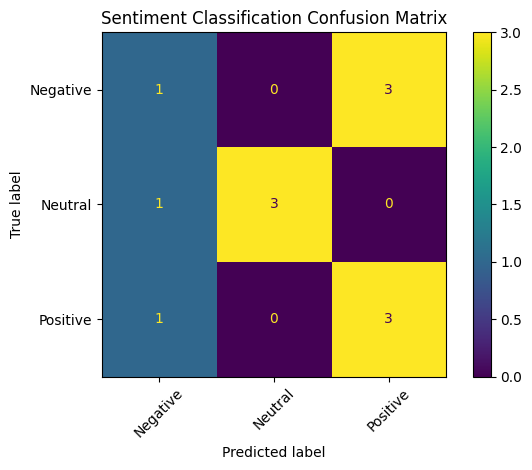

In [41]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation=45
)

plt.title("Sentiment Classification Confusion Matrix")
plt.tight_layout()
plt.show()

In [42]:
def predict_sentiment(text):
    cleaned = preprocess_text(text)
    features = vectorizer.transform([cleaned])
    prediction = model.predict(features)[0]
    probabilities = model.predict_proba(features)[0]

    print("Input:", text)
    print("Predicted Sentiment:", prediction)
    print("Confidence:", round(max(probabilities) * 100, 2), "%")

predict_sentiment("I really enjoyed this product")

Input: I really enjoyed this product
Predicted Sentiment: Positive
Confidence: 52.44 %


In [43]:
predict_sentiment("This product is terrible and disappointing")

Input: This product is terrible and disappointing
Predicted Sentiment: Negative
Confidence: 45.7 %


In [44]:
predict_sentiment("The product was delivered today")

Input: The product was delivered today
Predicted Sentiment: Neutral
Confidence: 45.23 %


In [45]:
test_sentences = [
    "I absolutely love this product",
    "This is a terrible experience",
    "The package was delivered today",
    "The quality is fantastic",
    "I am very disappointed"
]

results = []

for text in test_sentences:
    cleaned = preprocess_text(text)
    features = vectorizer.transform([cleaned])
    prediction = model.predict(features)[0]

    results.append({
        "Input": text,
        "Prediction": prediction
    })

results_df = pd.DataFrame(results)
results_df

,Input,Prediction
0,I absolutely love this product,Positive
1,This is a terrible experience,Negative
2,The package was delivered today,Neutral
3,The quality is fantastic,Positive
4,I am very disappointed,Negative


In [46]:
import joblib

joblib.dump(
    (vectorizer, model),
    "sentiment_model.joblib"
)

print("Model saved successfully.")

Model saved successfully.


In [47]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [48]:
df[["text", "sentiment"]].to_csv(
    "sentiment_dataset.csv",
    index=False
)

print("Dataset saved.")

Dataset saved.
